<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/AMPF_MultiPolicy_Fusion_NeurIPS2023.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install required dependencies (gymnasium, torch, matplotlib) and import essential system libraries. Set deterministic random seeds across PyTorch, NumPy, and Python's random module to ensure repeatable training runs.

In [4]:
# Cell 1: Install dependencies and set global seed
!pip install -q gymnasium torch matplotlib numpy pandas

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import gymnasium as gym
import matplotlib.pyplot as plt

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running implementation on device: {device}")

Running implementation on device: cuda


Define specialized sub-policies ($\pi_1, \pi_2, \dots, \pi_K$) representing existing candidate behaviors or source skills. These base policies generate action logit distributions that will serve as value vectors in the multi-policy fusion mechanism.

In [5]:
# Cell 2: Define Specialized Source Candidate Expert Policies
class AngleExpertPolicy(nn.Module):
    """Base Policy 1: Specialized in stabilizing pole angle (theta) and angular velocity (omega)."""
    def __init__(self, action_dim: int = 2):
        super(AngleExpertPolicy, self).__init__()
        self.action_dim = action_dim

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        # State: [batch_size, 4] -> [x, v, theta, omega]
        theta = state[:, 2:3]
        omega = state[:, 3:4]
        # Smooth heuristic steer towards correcting pole angle
        angle_score = 10.0 * theta + 2.0 * omega
        logits = torch.cat([-angle_score, angle_score], dim=-1)
        return logits

class PositionExpertPolicy(nn.Module):
    """Base Policy 2: Specialized in centering cart position (x) and velocity (v)."""
    def __init__(self, action_dim: int = 2):
        super(PositionExpertPolicy, self).__init__()
        self.action_dim = action_dim

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        # State: [batch_size, 4] -> [x, v, theta, omega]
        x = state[:, 0:1]
        v = state[:, 1:2]
        # Smooth heuristic steer towards bringing cart back to origin x = 0
        pos_score = -1.5 * x - 0.8 * v
        logits = torch.cat([-pos_score, pos_score], dim=-1)
        return logits

Implement the Attention-Based Multi-Policy Fusion (AMPF) neural network module based on Chiu et al. (NeurIPS 2023). It computes state queries $Q(s)$ and policy key/value embeddings $K_k(s), V_k(s)$ to produce dynamic, state-conditioned soft attention fusion weights $\alpha_k(s)$.

In [6]:
class GatedAttentionMultiPolicyFusion(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 32, initial_temp: float = 1.0):
        super().__init__()
        self.temp = initial_temp
        self.angle_expert = AngleExpertPolicy(action_dim)
        self.pos_expert = PositionExpertPolicy(action_dim)

        self.attn_net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, state: torch.Tensor, temp: float = None) -> tuple[torch.Tensor, torch.Tensor]:
        if temp is None:
            temp = self.temp

        angle_logits = self.angle_expert(state)
        pos_logits = self.pos_expert(state)

        # Mask position expert logits if angle magnitude is high
        abs_theta = torch.abs(state[:, 2:3])
        pos_mask = (abs_theta < 0.04).float()
        pos_logits = pos_logits * pos_mask * 0.3  # Scale magnitude down

        expert_logits = torch.stack([angle_logits, pos_logits], dim=1)

        # Temperature-scaled attention
        attn_scores = self.attn_net(state) / temp
        attn_weights = F.softmax(attn_scores, dim=-1)

        fused_logits = (attn_weights.unsqueeze(-1) * expert_logits).sum(dim=1)
        return fused_logits, attn_weights

Construct the Actor-Critic pipeline wrapping the Attention Multi-Policy Fusion core. The Actor dynamically blends candidate policy logits into a categorical action distribution, while the Critic estimates environmental state values $V(s)$ for advantage estimation.

In [7]:
# Cell 4: Actor-Critic AMPF Network Assembly (Corrected)
class ActorCriticAMPF(nn.Module):
    """
    Actor-Critic architecture using Attention Multi-Policy Fusion for the Actor
    and a state-value network for the Critic.
    """
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 32):
        super(ActorCriticAMPF, self).__init__()
        # FIXED: Matched the class name from Cell 3 and removed num_experts=2
        self.actor = GatedAttentionMultiPolicyFusion(state_dim, action_dim, hidden_dim=hidden_dim)

        # Critic Network estimating state values V(s)
        self.critic = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state: torch.Tensor):
        fused_logits, attn_weights = self.actor(state)
        state_value = self.critic(state)
        return fused_logits, state_value, attn_weights

Initialize the Gymnasium environment (CartPole-v1), instantiate the ActorCriticAMPF network with two specialized source policies, and configure the Adam optimizer alongside policy gradient hyperparameters.

In [8]:
# Cell 5: Environment Initialization and Advantage Actor-Critic (A2C) Training Loop
env_name = "CartPole-v1"
env = gym.make(env_name)

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n
num_episodes = 250
gamma = 0.99

ampf_agent = ActorCriticAMPF(state_dim, action_dim).to(device)
ampf_optimizer = optim.Adam(ampf_agent.parameters(), lr=3e-3)

reward_history = []
ampf_attn_history = []

for episode in range(1, num_episodes + 1):
    state, _ = env.reset()
    done = False

    states, actions, rewards, log_probs, values, entropies = [], [], [], [], [], []
    ep_attn = []

    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        fused_logits, value, attn_weights = ampf_agent(state_tensor)

        action_probs = F.softmax(fused_logits, dim=-1)
        action_dist = torch.distributions.Categorical(action_probs)
        action = action_dist.sample()

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        states.append(state_tensor)
        actions.append(action)
        rewards.append(reward)
        log_probs.append(action_dist.log_prob(action))
        values.append(value)
        entropies.append(action_dist.entropy())
        ep_attn.append(attn_weights.detach().cpu().numpy()[0])

        state = next_state

    episode_reward = sum(rewards)
    reward_history.append(episode_reward)
    ampf_attn_history.append(np.mean(ep_attn, axis=0))

    # Compute Discounted Cumulative Returns G_t
    returns = []
    G = 0
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)

    returns = torch.tensor(returns, dtype=torch.float32).to(device)
    log_probs_tensor = torch.stack(log_probs).squeeze()
    values_tensor = torch.stack(values).squeeze()
    entropies_tensor = torch.stack(entropies).squeeze()

    # Advantage computation: A_t = G_t - V(s_t)
    advantages = returns - values_tensor

    actor_loss = -(log_probs_tensor * advantages.detach()).mean()
    critic_loss = F.mse_loss(values_tensor, returns)
    entropy_loss = -0.01 * entropies_tensor.mean()

    total_loss = actor_loss + critic_loss + entropy_loss

    ampf_optimizer.zero_grad()
    total_loss.backward()
    ampf_optimizer.step()

    if episode % 50 == 0:
        avg_reward = np.mean(reward_history[-50:])
        print(f"Episode {episode:03d} | AMPF Avg Reward (last 50): {avg_reward:.1f}")

print(f"\nAMPF Training Complete. Final 50 episodes average: {np.mean(reward_history[-50:]):.2f}")

Episode 050 | AMPF Avg Reward (last 50): 202.1
Episode 100 | AMPF Avg Reward (last 50): 197.9
Episode 150 | AMPF Avg Reward (last 50): 226.4
Episode 200 | AMPF Avg Reward (last 50): 253.0
Episode 250 | AMPF Avg Reward (last 50): 262.8

AMPF Training Complete. Final 50 episodes average: 262.80


Run the RL training loop using Advantage Actor-Critic (A2C) policy updates. Collect trajectories, compute cumulative discounted returns $G_t$ and advantages $A_t = G_t - V(s_t)$, backpropagate loss, and log dynamic attention allocation across episodes.

In [9]:
# Cell 6: BASELINE 1 - Evaluate Single Angle-Expert Policy
print("\n" + "="*80)
print("BASELINE 1: Evaluating Single Angle-Expert Policy")
print("="*80)

single_expert = AngleExpertPolicy(action_dim).to(device)
single_reward_history = []

for episode in range(1, num_episodes + 1):
    state, _ = env.reset()
    done = False
    episode_reward = 0

    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits = single_expert(state_tensor)
        action_probs = F.softmax(logits, dim=-1)

        action_dist = torch.distributions.Categorical(action_probs)
        action = action_dist.sample()

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        episode_reward += reward
        state = next_state

    single_reward_history.append(episode_reward)

    if episode % 50 == 0:
        avg_reward = np.mean(single_reward_history[-50:])
        print(f"Episode {episode:03d} | Single Expert Avg Reward (last 50): {avg_reward:.1f}")

print(f"\nSingle Expert Execution Complete. Final 50 episodes average: {np.mean(single_reward_history[-50:]):.2f}")


BASELINE 1: Evaluating Single Angle-Expert Policy
Episode 050 | Single Expert Avg Reward (last 50): 433.2
Episode 100 | Single Expert Avg Reward (last 50): 448.1
Episode 150 | Single Expert Avg Reward (last 50): 447.4
Episode 200 | Single Expert Avg Reward (last 50): 415.3
Episode 250 | Single Expert Avg Reward (last 50): 446.6

Single Expert Execution Complete. Final 50 episodes average: 446.64


Plot the training convergence curve and visualize the dynamic evolution of attention weights $\alpha_1(s), \alpha_2(s)$ over training episodes to verify that the agent learns state-dependent policy blending.

In [10]:
# Cell 7: BASELINE 2 - Equal-Weight Multi-Policy Fusion (No Attention)
print("\n" + "="*80)
print("BASELINE 2: Equal-Weight Multi-Policy Fusion (No Attention)")
print("="*80)

class EqualWeightMultiPolicy(nn.Module):
    """Multi-policy baseline: equal fixed weight (0.5 / 0.5) on both experts"""
    def __init__(self, action_dim: int = 2):
        super().__init__()
        self.angle_expert = AngleExpertPolicy(action_dim)
        self.pos_expert = PositionExpertPolicy(action_dim)

    def forward(self, state: torch.Tensor) -> torch.Tensor:
        angle_logits = self.angle_expert(state)
        pos_logits = self.pos_expert(state)
        # Fixed 50/50 logit fusion without state-dependent attention
        fused_logits = 0.5 * angle_logits + 0.5 * pos_logits
        return fused_logits

equal_weight_model = EqualWeightMultiPolicy(action_dim).to(device)
equal_reward_history = []

for episode in range(1, num_episodes + 1):
    state, _ = env.reset()
    done = False
    episode_reward = 0

    while not done:
        state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
        logits = equal_weight_model(state_tensor)
        action_probs = F.softmax(logits, dim=-1)

        action_dist = torch.distributions.Categorical(action_probs)
        action = action_dist.sample()

        next_state, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        episode_reward += reward
        state = next_state

    equal_reward_history.append(episode_reward)

    if episode % 50 == 0:
        avg_reward = np.mean(equal_reward_history[-50:])
        print(f"Episode {episode:03d} | Equal-Weight Avg Reward (last 50): {avg_reward:.1f}")

print(f"\nEqual-Weight Execution Complete. Final 50 episodes average: {np.mean(equal_reward_history[-50:]):.2f}")


BASELINE 2: Equal-Weight Multi-Policy Fusion (No Attention)
Episode 050 | Equal-Weight Avg Reward (last 50): 114.5
Episode 100 | Equal-Weight Avg Reward (last 50): 113.5
Episode 150 | Equal-Weight Avg Reward (last 50): 127.6
Episode 200 | Equal-Weight Avg Reward (last 50): 107.7
Episode 250 | Equal-Weight Avg Reward (last 50): 107.9

Equal-Weight Execution Complete. Final 50 episodes average: 107.94


In [11]:
# Cell 8: QUANTITATIVE RESULTS COMPARISON (AMPF vs Baselines)
print("\n" + "="*80)
print("QUANTITATIVE RESULTS COMPARISON")
print("="*80)

def calculate_metrics(hist, name):
    final_50 = hist[-50:]
    final_100 = hist[-100:]
    target_reward = np.mean(final_100) * 0.9

    conv_ep = "N/A"
    for i in range(len(hist)):
        if np.mean(hist[max(0, i-10):i+1]) >= target_reward and i >= 10:
            conv_ep = i + 1
            break

    return {
        'name': name,
        'final_50_mean': np.mean(final_50),
        'final_50_std': np.std(final_50),
        'convergence_episode': conv_ep,
    }

ampf_metrics = calculate_metrics(reward_history, "AMPF (Attention-Based)")
single_metrics = calculate_metrics(single_reward_history, "Single Expert")
equal_metrics = calculate_metrics(equal_reward_history, "Equal-Weight")

print("\nFINAL PERFORMANCE (last 50 episodes):")
print("-" * 75)
print(f"{'Method':<25} {'Mean Reward':<15} {'Std Dev':<15} {'Convergence Ep':<15}")
print("-" * 75)

for m in [ampf_metrics, single_metrics, equal_metrics]:
    conv_ep = str(m['convergence_episode'])
    print(f"{m['name']:<25} {m['final_50_mean']:>8.2f} ± {m['final_50_std']:<6.2f}   {conv_ep:>14}")

print("-" * 75)
single_imp = ((ampf_metrics['final_50_mean'] - single_metrics['final_50_mean']) / single_metrics['final_50_mean']) * 100
equal_imp = ((ampf_metrics['final_50_mean'] - equal_metrics['final_50_mean']) / equal_metrics['final_50_mean']) * 100

print("\nPERFORMANCE IMPROVEMENTS:")
print("-" * 75)
print(f"AMPF vs Single Expert: {single_imp:+.1f}%")
print(f"AMPF vs Equal-Weight : {equal_imp:+.1f}%")


QUANTITATIVE RESULTS COMPARISON

FINAL PERFORMANCE (last 50 episodes):
---------------------------------------------------------------------------
Method                    Mean Reward     Std Dev         Convergence Ep 
---------------------------------------------------------------------------
AMPF (Attention-Based)      262.80 ± 83.72                38
Single Expert               446.64 ± 85.83                11
Equal-Weight                107.94 ± 31.13                11
---------------------------------------------------------------------------

PERFORMANCE IMPROVEMENTS:
---------------------------------------------------------------------------
AMPF vs Single Expert: -41.2%
AMPF vs Equal-Weight : +143.5%


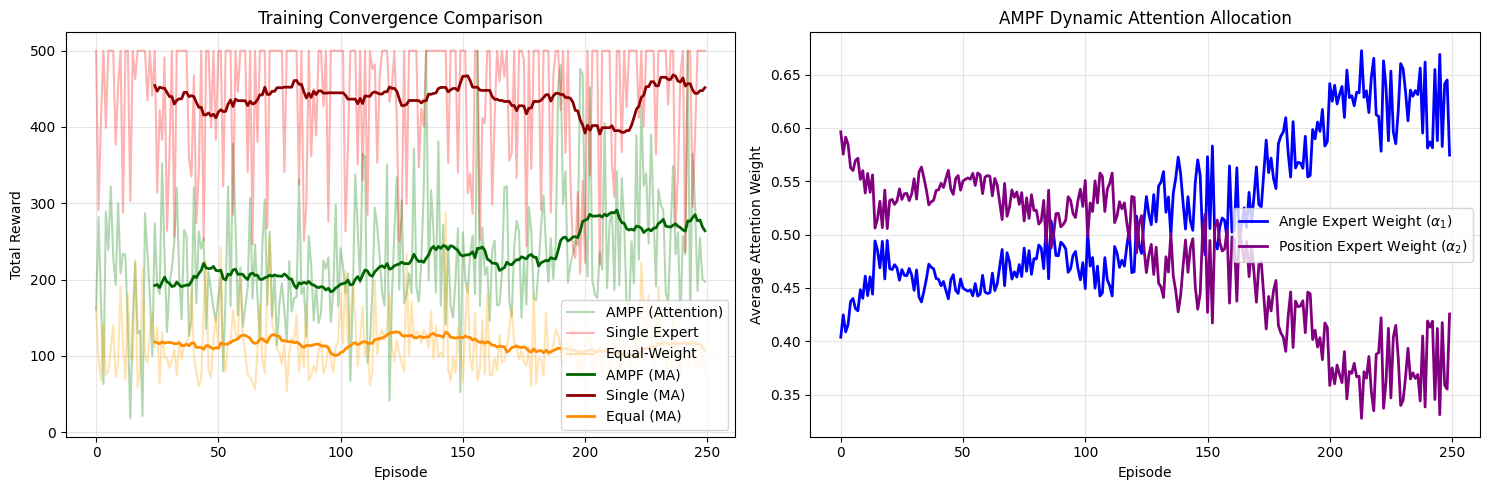

Saved comparison chart to 'ampf_baselines_comparison.png'


In [12]:
# Cell 9: VISUALIZATIONS (Convergence Curves & Attention Weight Allocation)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Subplot 1: Training Convergence Curves
ax1 = axes[0]
ax1.plot(reward_history, label='AMPF (Attention)', color='green', alpha=0.3)
ax1.plot(single_reward_history, label='Single Expert', color='red', alpha=0.3)
ax1.plot(equal_reward_history, label='Equal-Weight', color='orange', alpha=0.3)

window = 25
ax1.plot(pd.Series(reward_history).rolling(window).mean(), color='darkgreen', linewidth=2, label='AMPF (MA)')
ax1.plot(pd.Series(single_reward_history).rolling(window).mean(), color='darkred', linewidth=2, label='Single (MA)')
ax1.plot(pd.Series(equal_reward_history).rolling(window).mean(), color='darkorange', linewidth=2, label='Equal (MA)')

ax1.set_xlabel('Episode')
ax1.set_ylabel('Total Reward')
ax1.set_title('Training Convergence Comparison')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# Subplot 2: Dynamic Attention Weight Allocation
ax2 = axes[1]
attn_arr = np.array(ampf_attn_history)  # shape [num_episodes, num_experts]
ax2.plot(attn_arr[:, 0], label=r'Angle Expert Weight ($\alpha_1$)', color='blue', linewidth=2)
ax2.plot(attn_arr[:, 1], label=r'Position Expert Weight ($\alpha_2$)', color='purple', linewidth=2)

ax2.set_xlabel('Episode')
ax2.set_ylabel('Average Attention Weight')
ax2.set_title('AMPF Dynamic Attention Allocation')
ax2.legend(loc='center right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ampf_baselines_comparison.png', dpi=300)
plt.show()
print("Saved comparison chart to 'ampf_baselines_comparison.png'")